In [1]:
## change working directory to the root
import os
root_marker = 'setup.py'
current_dir = os.getcwd()
if not os.path.exists(os.path.join(current_dir, root_marker)):
    parent_dir = os.path.dirname(current_dir)
    os.chdir(parent_dir)
    # print(f"Working directory changed to: {os.getcwd()}")
# else:
    # print(f"Already at the root directory: {os.getcwd()}")
    
## import utility functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tests.plot_all_utils import *

## simulation settings
import json
with open('tests/settings.json', 'r') as f:
    settings = json.load(f)
output_dir = settings['output_dir']
alp = settings['alp']
nsim = settings['nsim']
null_seed = settings['null_seed']
null_p = settings['null_p']
null_N = settings['null_N']
null_n = settings['null_n']
null_P = settings['null_P']
roc_seed = settings['roc_seed']
roc_p = null_p
roc_N = null_N
roc_n = null_n
roc_P = null_P
print(f"Output Directory: {output_dir}")
print(f"Number of Simulations: {nsim}")
print(f"NULL parameters: {null_p}, {null_N}, {null_n}, {null_P}")
print(f"ROC parameters: {roc_p}, {roc_N}, {roc_n}, {roc_P}")
os.makedirs(os.path.join(output_dir, 'res'), exist_ok=True)

## methods to test
methods_to_plot = 'all'
STTM_N = [5, 10, 15, 20]
METHODS = [f"medtree_sttm_n{n}" for n in STTM_N]
if methods_to_plot == 'all':
    STTM_N = [10]
    METHODS = [f"medtree_sttm_n{n}" for n in STTM_N]
    METHODS.extend(["CDIT", "CCIT", "CMIknn", "RCIT", "GCM", "wGCM", "LPCIT"])
# METHODS.reverse()
print(METHODS)

Output Directory: data/Aaa
Number of Simulations: 500
NULL parameters: 10, [50, 100, 200, 400, 800, 1600, 3200], 800, [2, 4, 8, 16, 32, 64, 128]
ROC parameters: 10, [50, 100, 200, 400, 800, 1600, 3200], 800, [2, 4, 8, 16, 32, 64, 128]
['medtree_sttm_n10', 'CDIT', 'CCIT', 'CMIknn', 'RCIT', 'GCM', 'wGCM', 'LPCIT']


In [2]:
viridis = plt.get_cmap("viridis")
to_hex = lambda rgba: '#{:02x}{:02x}{:02x}'.format(
    int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255)
)
levels = ["sttm_n5", "sttm_n10", "sttm_n15", "sttm_n20", "sttm_n25"]
viridis_colors = [to_hex(viridis(i)) for i in np.linspace(0, 1, len(levels))]
color_map = {
    f"medtree_{lvl}": col
    for lvl, col in zip(levels, viridis_colors)
}
color_map.update({
    "GCM":    "#117733",
    "wGCM":   "#44AA99",
    "CCIT":   "#88CCEE",
    "RCIT":   "#DDCC77",
    "CMIknn": "#CC6677",
    "LPCIT":  "#AA4499",
    "CDIT":   "#999933",
    "Extra":  "#882255",
})
scale = 0.6

## Simulation 1. Assessing Type 1 error rate control

Error doing file 'data/Aaa/null_n1600p10_CDIT_pvals.csv': data/Aaa/null_n1600p10_CDIT_pvals.csv not found.
Error doing file 'data/Aaa/null_n3200p10_CDIT_pvals.csv': data/Aaa/null_n3200p10_CDIT_pvals.csv not found.
Error doing file 'data/Aaa/null_n1600p10_CDIT_times.csv': data/Aaa/null_n1600p10_CDIT_times.csv not found.
Error doing file 'data/Aaa/null_n3200p10_CDIT_times.csv': data/Aaa/null_n3200p10_CDIT_times.csv not found.


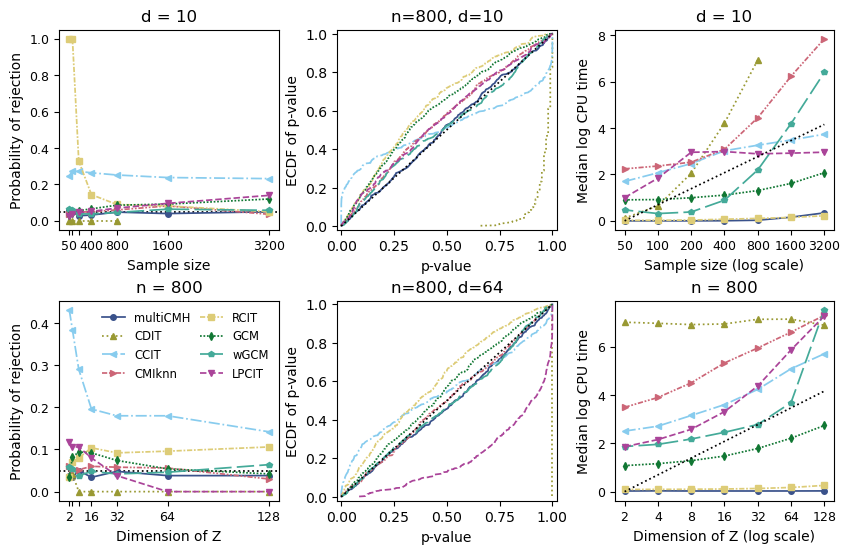

In [3]:
prefix = 'null'
N = null_N
p = null_p
fig = plt.figure(figsize = (14*scale, 9*scale))
gs =gridspec.GridSpec(2,3)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
plot_lines(ax1, output_dir, prefix, N, p, "Probability of rejection", METHODS, nsim, color_map, show_legend=False)
# plot_lines(ax2, output_dir, prefix, N, p, "KS statistic", METHODS, nsim, color_map)
plot_ecdf(ax2, output_dir, N[4], p, METHODS, nsim, color_map)
plot_lines(ax3, output_dir, prefix, N, p, "Median log CPU time", METHODS, nsim, color_map, show_legend=False)
# plot_times(ax3, output_dir, prefix, N, p, METHODS, nsim, color_map)
# plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'res', prefix + f'_{os.path.basename(output_dir)}_{methods_to_plot}_fixedp{p}.png'), dpi=300)
# plt.show()

n = null_n
P = null_P
# fig = plt.figure(figsize = (14, 5))
# gs =gridspec.GridSpec(1,3)
ax4 = fig.add_subplot(gs[1,0])
ax5 = fig.add_subplot(gs[1,1])
ax6 = fig.add_subplot(gs[1,2])
plot_lines(ax4, output_dir, prefix, n, P, "Probability of rejection", METHODS, nsim, color_map, show_legend=True)
# plot_lines(ax2, output_dir, prefix, n, P, "KS statistic", METHODS, nsim, color_map)
plot_ecdf(ax5, output_dir, n, P[-2], METHODS, nsim, color_map)
plot_lines(ax6, output_dir, prefix, n, P, "Median log CPU time", METHODS, nsim, color_map, show_legend=False)
# plot_times(ax3, output_dir, prefix, N, p, METHODS, nsim, color_map)
plt.tight_layout(pad=0, w_pad=-0.05, h_pad=0.5, rect=[0, 0, 0.99, 0.99])
# plt.savefig(os.path.join(output_dir, 'res', prefix + f'_{os.path.basename(output_dir)}_{methods_to_plot}_T1E.pdf'))
plt.show()

## Simulation 2: Calculating area under ROC

Error doing file 'data/Aaa/roc_n1600p10_CDIT_pvals.csv': data/Aaa/roc_n1600p10_CDIT_pvals.csv not found.
Error doing file 'data/Aaa/roc_n3200p10_CDIT_pvals.csv': data/Aaa/roc_n3200p10_CDIT_pvals.csv not found.
Error doing file 'data/Aaa/roc_n3200p10_CDIT_pvals.csv': data/Aaa/roc_n3200p10_CDIT_pvals.csv not found.


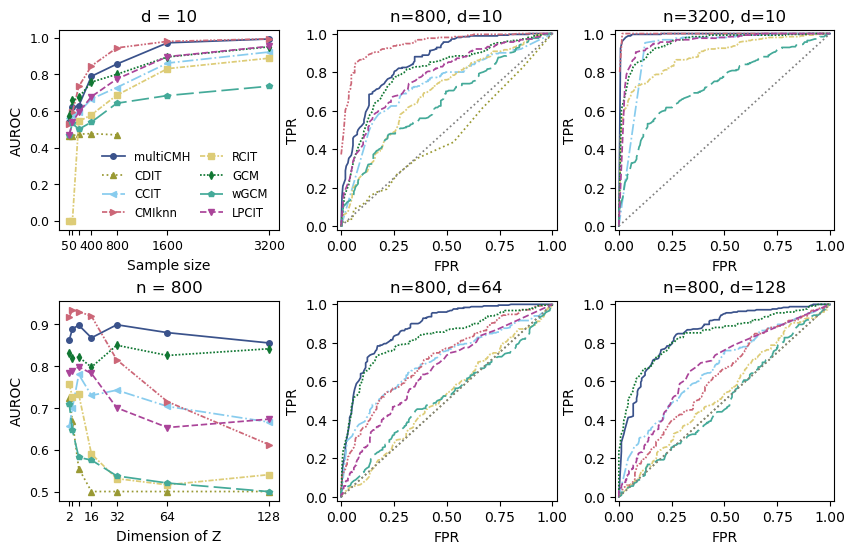

In [4]:
prefix = 'roc'
oracle = is_alt(np.arange(0, nsim), nsim)
fig, axes = plt.subplots(2, 3, figsize = (14*scale, 9*scale))

N = roc_N
p = roc_p
plot_lines(axes[0, 0], output_dir, prefix, N, p, "AUROC", METHODS, nsim, color_map, oracle = oracle, show_legend=True)
plot_rocs(axes[0, 1], output_dir, N[4], p, METHODS, nsim, color_map, oracle=oracle)
plot_rocs(axes[0, 2], output_dir, N[-1], p, METHODS, nsim, color_map, oracle=oracle, show_legend=False)

# FIXED N, INCREASING P
n = roc_n
P = roc_P
plot_lines(axes[1, 0], output_dir, prefix, n, P, "AUROC", METHODS, nsim, color_map, oracle = oracle, show_legend=False)
plot_rocs(axes[1, 1], output_dir, n, P[-2], METHODS, nsim, color_map, oracle=oracle)
plot_rocs(axes[1, 2], output_dir, n, P[-1], METHODS, nsim, color_map, oracle=oracle)

plt.tight_layout(pad=0, w_pad=-0.05, h_pad=0.5, rect=[0, 0, 0.99, 0.99])
# plt.savefig(os.path.join(output_dir, 'res', prefix + f'_{os.path.basename(output_dir)}_{methods_to_plot}_ROC.pdf'))
plt.show()